In [1]:
from neuralforecast.utils import AirPassengersDF

In [2]:
Y_df = AirPassengersDF
Y_df.reset_index(drop=True, inplace = True)
Y_df.head()

,unique_id,ds,y
0,1.0,1949-01-31,112.0
1,1.0,1949-02-28,118.0
2,1.0,1949-03-31,132.0
3,1.0,1949-04-30,129.0
4,1.0,1949-05-31,121.0


In [3]:
from ray import tune

from neuralforecast.core import NeuralForecast
from neuralforecast.auto import AutoMLP
from neuralforecast.models import NBEATS, NHITS, TimesNet

In [4]:
horizon = 12
models = [TimesNet(input_size=2 * horizon, h=horizon, max_steps=50),
          NBEATS(input_size=2 * horizon, h=horizon, max_steps=50),
          NHITS(input_size=2 * horizon, h=horizon, max_steps=50),
          AutoMLP(# Ray tune explore config
                  config=dict(max_steps=100, # Operates with steps not epochs
                              input_size=tune.choice([3*horizon]),
                              learning_rate=tune.choice([1e-3])),
                  h=horizon,
                  num_samples=1)]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\utilities\parsing.py:199: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
Seed set to 1
Seed set to 1
Seed set to 1


In [5]:
nf = NeuralForecast(models=models, freq='M')
nf.fit(df=Y_df)

(_train_tune pid=2032) c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\ray\tune\integration\pytorch_lightning.py:194: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=2032) c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\utilities\parsing.py:199: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
(_train_tune pid=2032) c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\utilities\parsing.py:199: Attribute 'valid_loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['valid_loss'])`.
(_train_tune pid=2032) Seed set to 1
(_train_tune pid=2032) GPU available: True (cuda), used: True


Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]


(_train_tune pid=2032) c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\utilities\data.py:77: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 1. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
(_train_tune pid=2032) c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
(_train_tune pid=2032) c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\loops\fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 76: 100%|██████████| 1/1 [00:00<?, ?it/s, v_num=0, train_loss_step=13.90, train_loss_epoch=13.90]


(_train_tune pid=2032) `Trainer.fit` stopped: `max_steps=100` reached.
2024-04-18 15:47:50,526	INFO tune.py:1016 -- Wrote the latest version of all result files and experiment state to 'C:/Users/msz30/ray_results/_train_tune_2024-04-18_15-47-40' in 0.0156s.
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\utilities\parsing.py:199: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\utilities\parsing.py:199: Attribute 'valid_loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['valid_loss'])`.
Seed set to 1


...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\loops\fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.


In [6]:
Y_hat_df = nf.predict().reset_index()
Y_hat_df.head()

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\tsdataset.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.temporal = torch.tensor(temporal, dtype=torch.float)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\core.py:184: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


,unique_id,ds,TimesNet,NBEATS,NHITS,AutoMLP
0,1.0,1961-01-31,449.519104,442.860168,449.903351,470.698853
1,1.0,1961-02-28,435.712402,464.902832,467.601257,435.726898
2,1.0,1961-03-31,480.113770,473.652832,477.462585,462.640472
3,1.0,1961-04-30,528.215698,492.423553,508.574402,506.711273
4,1.0,1961-05-31,599.688538,533.610596,561.597473,524.766602


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import math

(-252.0, -97.0)


<Figure size 1200x300 with 0 Axes>

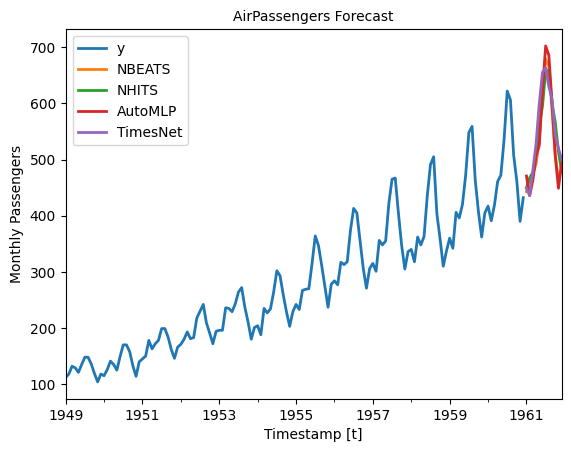

In [8]:
plot_df = pd.concat([Y_df, Y_hat_df]).set_index('ds') # Concatenate the train and forecast dataframes

plt.figure(figsize = (12, 3))
plot_df[['y', 'NBEATS', 'NHITS', 'AutoMLP', 'TimesNet']].plot(linewidth=2)

plt.title('AirPassengers Forecast', fontsize=10)
plt.ylabel('Monthly Passengers', fontsize=10)
plt.xlabel('Timestamp [t]', fontsize=10)
# plt.axvline(x=plot_df.index[-horizon], color='k', linestyle='--', linewidth=2)
plt.axvline(x=1961, color='k', linestyle='--', linewidth=2)
plt.legend(prop={'size': 10})
print(plt.xlim())
plt.show()

In [21]:
nf.save('models/models_airpassengers', model_index=[0], save_dataset=False, overwrite=True)

In [10]:
len_to_cut = int(len(Y_df)/2)
Y_df_2 = Y_df.iloc[:len_to_cut]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\tsdataset.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.temporal = torch.tensor(temporal, dtype=torch.float)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\core.py:184: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


<Figure size 1200x300 with 0 Axes>

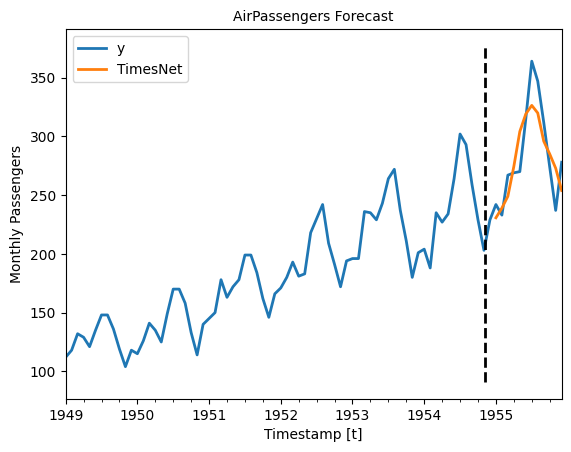

In [76]:
Y_hat_df_2 = nf.predict(df=Y_df_2).set_index('ds')

Y_hat_df_2['y'] = Y_df['y'][len_to_cut:len_to_cut+horizon].to_numpy()

plot_df_2 = pd.concat([Y_df_2.set_index('ds'), Y_hat_df_2]) # Concatenate the train and forecast dataframes

plt.figure(figsize = (12, 3))
plot_df_2[['y', 'TimesNet']].plot(linewidth=2)

plt.title('AirPassengers Forecast', fontsize=10)
plt.ylabel('Monthly Passengers', fontsize=10)
plt.xlabel('Timestamp [t]', fontsize=10)
plt.legend(prop={'size': 10})
plt.vlines(x=plt.xlim()[0]+(1-(len(Y_hat_df_2)-1)/(len(Y_df_2)-1))*(plt.xlim()[1]-plt.xlim()[0]), ymin=plt.ylim()[0], ymax=plt.ylim()[1], color='k', linestyle='--', linewidth=2)
plt.show()


In [68]:
math.ceil(1-len(Y_hat_df_2)/len(Y_df_2))

1